<a href="https://colab.research.google.com/github/RyantRamadhan/ImamAryantaRamadhan_2411532001_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load dataset
dataset_url = 'https://raw.githubusercontent.com/RyantRamadhan/ImamAryantaRamadhan_2411532001_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv'
df = pd.read_csv(dataset_url)
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

THRESHOLD: 0.5 
Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



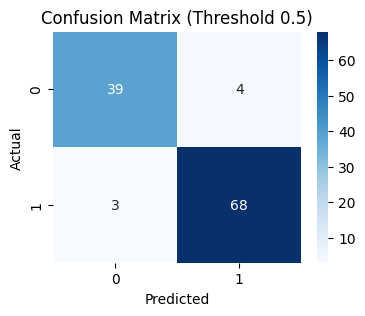

THRESHOLD: 0.7 
Accuracy: 0.9298

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91        43
           1       0.98      0.90      0.94        71

    accuracy                           0.93       114
   macro avg       0.92      0.94      0.93       114
weighted avg       0.94      0.93      0.93       114



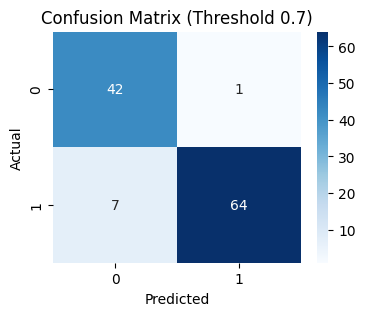

THRESHOLD: 0.9 
Accuracy: 0.8509

Classification Report:
              precision    recall  f1-score   support

           0       0.72      1.00      0.83        43
           1       1.00      0.76      0.86        71

    accuracy                           0.85       114
   macro avg       0.86      0.88      0.85       114
weighted avg       0.89      0.85      0.85       114



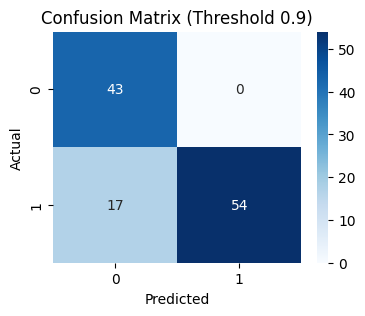

In [ ]:
def evaluate_threshold(model, X_test, y_test, threshold):
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)

    print(f"THRESHOLD: {threshold} ")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (Threshold {threshold})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

for t in [0.5, 0.7, 0.9]:
    evaluate_threshold(model, X_test_scaled, y_test, t)

In [ ]:
model_no_scaling = LogisticRegression(max_iter=1000)
model_no_scaling.fit(X_train, y_train)
acc_no_scaling = accuracy_score(y_test, model_no_scaling.predict(X_test))
acc_scaling = accuracy_score(y_test, model.predict(X_test_scaled))

print(f"Akurasi TANPA Scaling: {acc_no_scaling:.4f}")
print(f"Akurasi DENGAN Scaling: {acc_scaling:.4f}")

Akurasi TANPA Scaling: 0.9298
Akurasi DENGAN Scaling: 0.9386
